# Telco Customer Churn – Machine Learning Capstone Project

This project analyses the Telco Customer Churn dataset and develops
machine learning models to predict whether a customer is likely to churn.

The project includes data inspection, preprocessing, exploratory data
visualisation, logistic regression, random forest classification and
model evaluation.

In [1]:
# Import libraries for data analysis and visualisation

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score,
    recall_score
)

In [2]:
# Load the Telco Customer Churn dataset

telecom_cust = pd.read_csv(
    "Telco-Customer-Churn.csv"
)

In [3]:
# Display the first 10 rows of the dataset

telecom_cust.head(10)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


In [4]:
# Display all column names

print("Dataset columns:")

for column in telecom_cust.columns:
    print(column)

Dataset columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn


In [5]:
# Display the data type of each column

print(telecom_cust.dtypes)

customerID              str
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object


In [6]:
# Convert TotalCharges to numeric.
# Invalid or blank values are converted to NaN.

telecom_cust["TotalCharges"] = pd.to_numeric(
    telecom_cust["TotalCharges"],
    errors="coerce"
)

In [7]:
print(
    "TotalCharges data type:",
    telecom_cust["TotalCharges"].dtype
)

print(
    "Missing TotalCharges values:",
    telecom_cust["TotalCharges"].isnull().sum()
)

TotalCharges data type: float64
Missing TotalCharges values: 11


In [8]:
# Check for missing values in the dataset

print(telecom_cust.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [9]:
# Remove rows containing missing values

telecom_cust = telecom_cust.dropna()

# Confirm that all missing values have been removed
print(
    "Total missing values after cleaning:",
    telecom_cust.isnull().sum().sum()
)

print(
    "Number of rows after cleaning:",
    len(telecom_cust)
)

Total missing values after cleaning: 0
Number of rows after cleaning: 7032


In [10]:
# Remove the customerID column because it is an identifier
# and is not useful as a predictor of customer churn.

telecom_cust = telecom_cust.drop(
    "customerID",
    axis=1
)

print(telecom_cust.columns)

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')


In [11]:
# Convert Churn into binary numeric values:
# Yes = 1 and No = 0

telecom_cust["Churn"] = telecom_cust[
    "Churn"
].map({
    "Yes": 1,
    "No": 0
})

# Check the converted values
print(
    telecom_cust["Churn"].value_counts()
)

Churn
0    5163
1    1869
Name: count, dtype: int64


In [12]:
# Convert categorical variables into dummy variables.
# drop_first=True removes one category from each categorical feature
# to reduce redundant dummy variables.

telecom_cust_dummies = pd.get_dummies(
    telecom_cust,
    drop_first=True,
    dtype=int
)

# Display the first five rows
telecom_cust_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,...,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,...,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,...,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,...,0,0,0,0,0,0,1,0,1,0


In [13]:
# Check the processed dataset

print(
    "Shape of processed dataset:",
    telecom_cust_dummies.shape
)

print(
    "\nRemaining data types:"
)

print(
    telecom_cust_dummies.dtypes.value_counts()
)

Shape of processed dataset: (7032, 31)

Remaining data types:
int64      29
float64     2
Name: count, dtype: int64


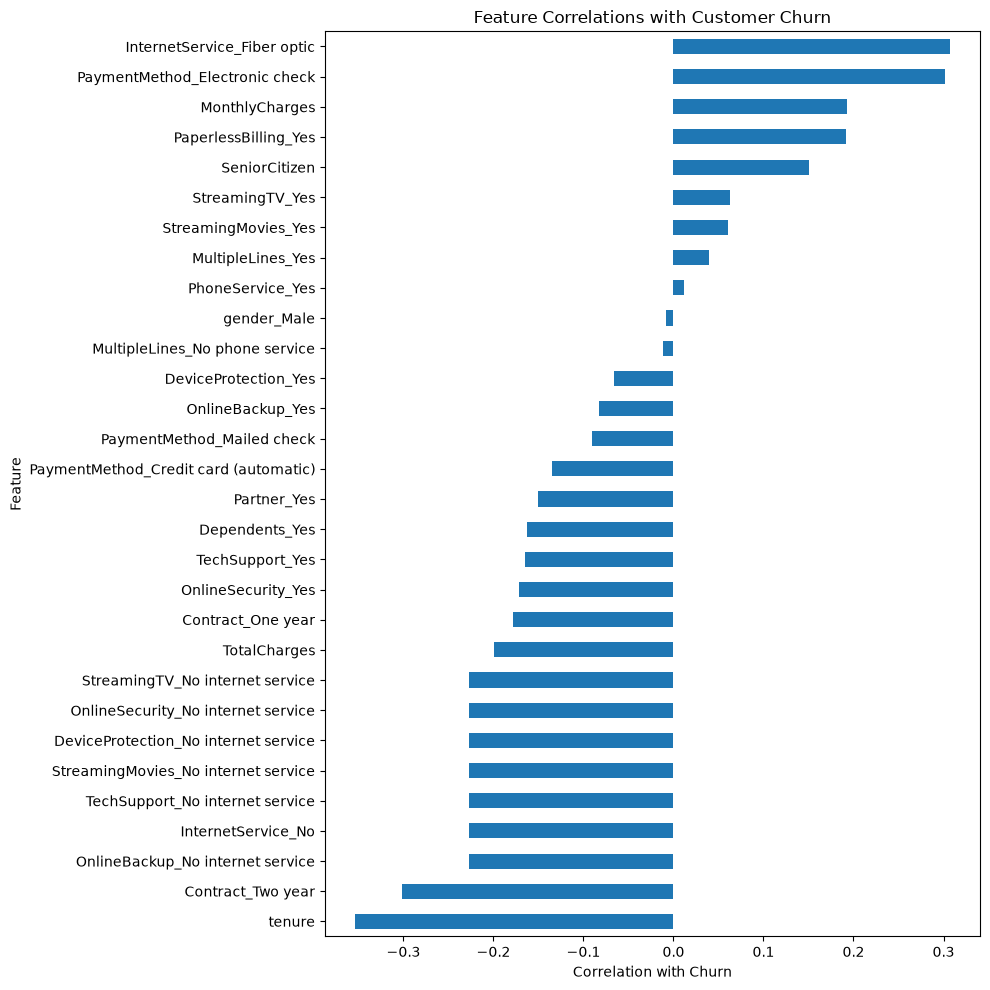

In [14]:
# Calculate the correlation of each feature with Churn

churn_correlations = (
    telecom_cust_dummies
    .corr()["Churn"]
    .sort_values()
)

# Plot correlations with Churn

plt.figure(figsize=(10, 10))

churn_correlations.drop("Churn").plot(
    kind="barh"
)

plt.xlabel("Correlation with Churn")
plt.ylabel("Feature")
plt.title("Feature Correlations with Customer Churn")

plt.tight_layout()
plt.show()

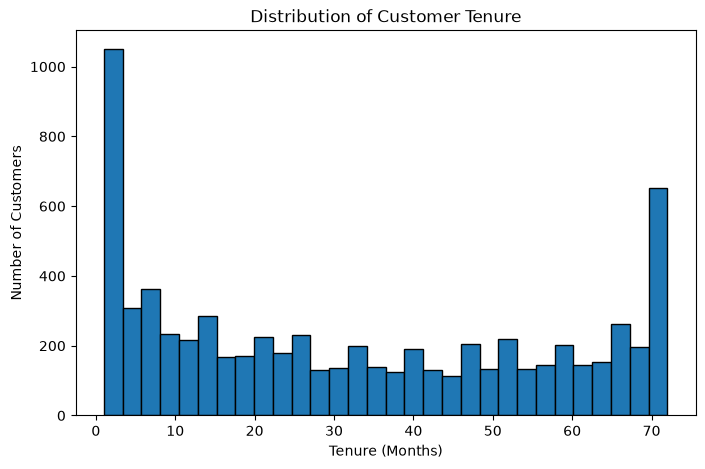

In [15]:
# Create a histogram of customer tenure

plt.figure(figsize=(8, 5))

plt.hist(
    telecom_cust["tenure"],
    bins=30,
    edgecolor="black"
)

plt.xlabel("Tenure (Months)")
plt.ylabel("Number of Customers")
plt.title("Distribution of Customer Tenure")

plt.show()

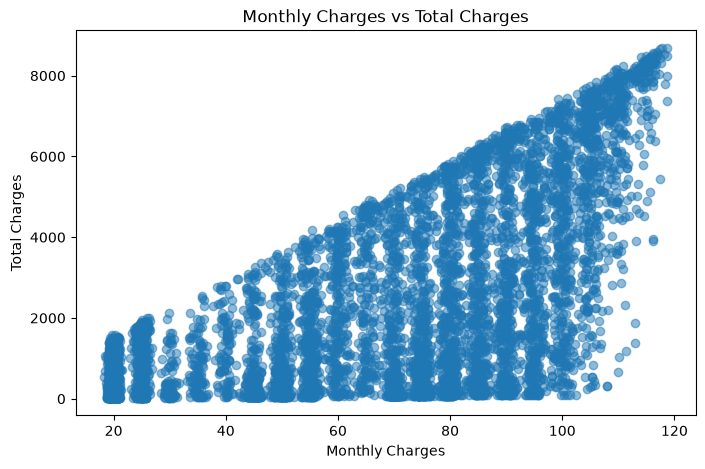

In [16]:
# Create a scatter plot of MonthlyCharges vs TotalCharges

plt.figure(figsize=(8, 5))

plt.scatter(
    telecom_cust["MonthlyCharges"],
    telecom_cust["TotalCharges"],
    alpha=0.5
)

plt.xlabel("Monthly Charges")
plt.ylabel("Total Charges")
plt.title("Monthly Charges vs Total Charges")

plt.show()

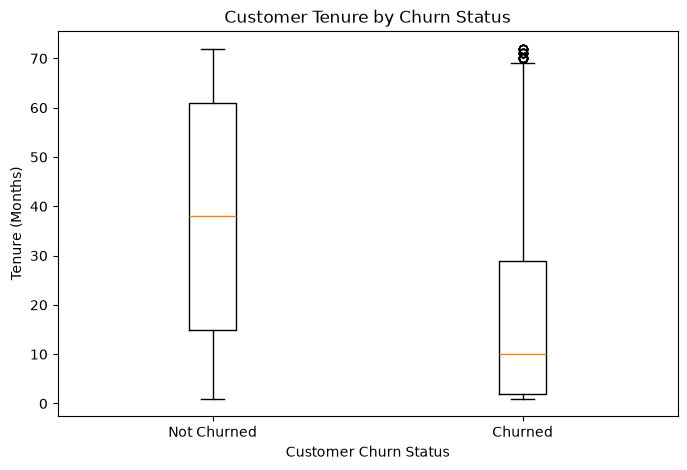

In [19]:
# Compare tenure for customers who churned
# and customers who did not churn.

non_churned_tenure = telecom_cust.loc[
    telecom_cust["Churn"] == 0,
    "tenure"
]

churned_tenure = telecom_cust.loc[
    telecom_cust["Churn"] == 1,
    "tenure"
]

plt.figure(figsize=(8, 5))

plt.boxplot(
    [
        non_churned_tenure,
        churned_tenure
    ],
    tick_labels=[
        "Not Churned",
        "Churned"
    ]
)

plt.xlabel("Customer Churn Status")
plt.ylabel("Tenure (Months)")
plt.title("Customer Tenure by Churn Status")

plt.show()

In [20]:
# Separate the independent variables from the target variable

X = telecom_cust_dummies.drop(
    "Churn",
    axis=1
)

y = telecom_cust_dummies["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 30)
y shape: (7032,)


In [21]:
# Create the Min-Max scaler

scaler = MinMaxScaler()

# Scale all independent variables to the range 0 to 1

X_scaled = scaler.fit_transform(X)

# Convert the scaled values back into a DataFrame
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

X_scaled.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.0,0.000000,0.115423,0.001275,0.0,1.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,0.0,0.464789,0.385075,0.215867,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.014085,0.354229,0.010310,1.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,0.0,0.619718,0.239303,0.210241,1.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.014085,0.521891,0.015330,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [22]:
# Check the minimum and maximum values after scaling

print(
    "Minimum scaled value:",
    X_scaled.min().min()
)

print(
    "Maximum scaled value:",
    X_scaled.max().max()
)

Minimum scaled value: 0.0
Maximum scaled value: 1.0


In [23]:
# Split the data into 75% training and 25% testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print(
    "Training set:",
    X_train.shape
)

print(
    "Test set:",
    X_test.shape
)

Training set: (5274, 30)
Test set: (1758, 30)


In [24]:
# Create the Logistic Regression model

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train the model

logistic_model.fit(
    X_train,
    y_train
)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

In [25]:
# Make predictions using the Logistic Regression model

logistic_predictions = logistic_model.predict(
    X_test
)

In [26]:
# Calculate Logistic Regression accuracy

logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

print(
    "Logistic Regression Accuracy:",
    round(logistic_accuracy, 4)
)

Logistic Regression Accuracy: 0.806


In [27]:
# Create the Random Forest classifier using the
# hyperparameters specified in the task.

random_forest_model = RandomForestClassifier(
    n_estimators=2000,
    oob_score=True,
    max_features="sqrt",
    max_leaf_nodes=50,
    bootstrap=True,
    random_state=42,
    n_jobs=-1
)

# Train the Random Forest model

random_forest_model.fit(
    X_train,
    y_train
)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",2000
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",50
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_true, y_pred)` to use acustom metric. Only available if `bootstrap=True`.For an illustration of out-of-bag (OOB) error estimation, see the example:ref:`sphx_glr_auto_examples_ensemble_plot_ensemble_oob.py`.",True
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel. :meth:`fit`, :meth:`predict`,:meth:`decision_path` and :meth:`apply` are all parallelized over thetrees. ``None`` means 1 unless in a :obj:`joblib.parallel_backend`context. ``-1`` means using all processors. See :term:`Glossary<n_jobs>` for more details.",-1
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the nod

In [28]:
# Make predictions using the Random Forest model

random_forest_predictions = (
    random_forest_model.predict(
        X_test
    )
)

In [29]:
# Calculate Random Forest accuracy

random_forest_accuracy = accuracy_score(
    y_test,
    random_forest_predictions
)

print(
    "Random Forest Accuracy:",
    round(random_forest_accuracy, 4)
)

Random Forest Accuracy: 0.7918


In [30]:
# Calculate the Out-of-Bag score and error

oob_score = random_forest_model.oob_score_

oob_error = 1 - oob_score

print(
    "OOB Score:",
    round(oob_score, 4)
)

print(
    "OOB Error:",
    round(oob_error, 4)
)

OOB Score: 0.7992
OOB Error: 0.2008


### Out-of-Bag Error Analysis

The Random Forest model achieved an Out-of-Bag (OOB) score of approximately
**79.92%**, resulting in an OOB error of approximately **20.08%**.

The OOB score provides an estimate of how well the Random Forest model is
likely to perform on unseen data because each tree can be evaluated using
observations that were not included in its bootstrap training sample.

The OOB error of 20.08% therefore indicates that approximately one-fifth of
the out-of-bag predictions were incorrect. This is reasonably consistent
with the model's test accuracy of approximately 79.18%, suggesting similar
performance on unseen observations.

In [31]:
# Create the Logistic Regression confusion matrix

logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print(
    "Logistic Regression Confusion Matrix:"
)

print(logistic_cm)

Logistic Regression Confusion Matrix:
[[1150  141]
 [ 200  267]]


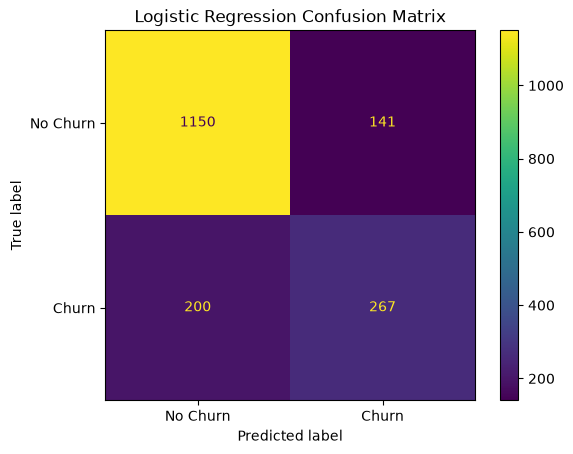

In [32]:
# Display the Logistic Regression confusion matrix

logistic_display = ConfusionMatrixDisplay(
    confusion_matrix=logistic_cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

logistic_display.plot()

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

### Logistic Regression Confusion Matrix Analysis

The Logistic Regression confusion matrix produced:

- **1,150 true negatives:** customers who did not churn and were correctly
  predicted as not churning.
- **141 false positives:** customers who did not churn but were incorrectly
  predicted as likely to churn.
- **200 false negatives:** customers who churned but were incorrectly
  predicted as not churning.
- **267 true positives:** customers who churned and were correctly predicted
  as likely to churn.

The model correctly identified many non-churning customers. However, it
failed to identify 200 customers who actually churned. In a customer churn
context, false negatives are particularly important because these customers
may leave without being identified for possible retention action.

In [33]:
# Create the Random Forest confusion matrix

random_forest_cm = confusion_matrix(
    y_test,
    random_forest_predictions
)

print(
    "Random Forest Confusion Matrix:"
)

print(random_forest_cm)

Random Forest Confusion Matrix:
[[1174  117]
 [ 249  218]]


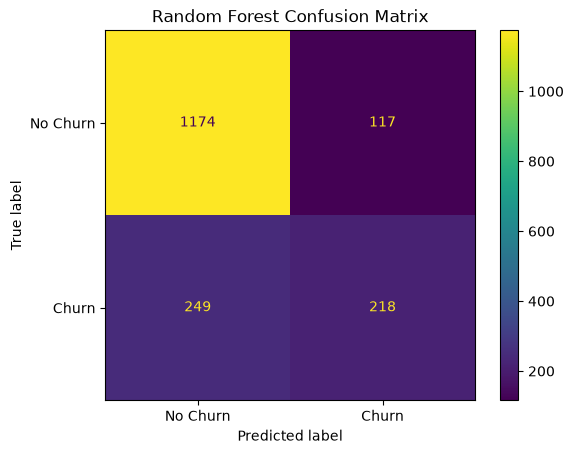

In [34]:
# Display the Random Forest confusion matrix

random_forest_display = ConfusionMatrixDisplay(
    confusion_matrix=random_forest_cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
)

random_forest_display.plot()

plt.title(
    "Random Forest Confusion Matrix"
)

plt.show()

### Random Forest Confusion Matrix Analysis

The Random Forest confusion matrix produced:

- **1,174 true negatives:** customers who did not churn and were correctly
  predicted as not churning.
- **117 false positives:** customers who did not churn but were incorrectly
  predicted as likely to churn.
- **249 false negatives:** customers who churned but were incorrectly
  predicted as not churning.
- **218 true positives:** customers who churned and were correctly predicted
  as likely to churn.

The Random Forest produced fewer false positives than Logistic Regression,
but it produced more false negatives. This means that it was more
conservative when predicting churn and consequently missed more customers
who actually churned.

In [35]:
# Calculate Logistic Regression precision and recall

logistic_precision = precision_score(
    y_test,
    logistic_predictions
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions
)

print(
    "Logistic Regression Precision:",
    round(logistic_precision, 4)
)

print(
    "Logistic Regression Recall:",
    round(logistic_recall, 4)
)

Logistic Regression Precision: 0.6544
Logistic Regression Recall: 0.5717


In [36]:
# Calculate Random Forest precision and recall

random_forest_precision = precision_score(
    y_test,
    random_forest_predictions
)

random_forest_recall = recall_score(
    y_test,
    random_forest_predictions
)

print(
    "Random Forest Precision:",
    round(random_forest_precision, 4)
)

print(
    "Random Forest Recall:",
    round(random_forest_recall, 4)
)

Random Forest Precision: 0.6507
Random Forest Recall: 0.4668


### Precision and Recall Analysis

Logistic Regression achieved a precision of approximately **65.44%** and a
recall of approximately **57.17%**. This means that about 65.44% of the
customers predicted to churn actually churned, while the model identified
about 57.17% of all customers who actually churned.

The Random Forest achieved a precision of approximately **65.07%** and a
recall of approximately **46.68%**. Its precision was therefore very similar
to Logistic Regression, but its recall was substantially lower.

For customer churn prediction, recall is particularly important when the
business objective is to identify as many customers at risk of leaving as
possible. A false negative represents a customer who actually churns but is
not identified by the model. Such customers may therefore be missed by
retention efforts.

There is a trade-off between precision and recall. Increasing recall can
result in more customers being flagged as potential churners, which may also
increase false positives and reduce precision. In this case, Logistic
Regression provides the better balance because it achieves slightly higher
precision while also identifying a substantially larger proportion of the
customers who actually churned.

In [37]:
# Compare the performance of the two models

model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        random_forest_accuracy
    ],
    "Precision": [
        logistic_precision,
        random_forest_precision
    ],
    "Recall": [
        logistic_recall,
        random_forest_recall
    ]
})

model_comparison

,Model,Accuracy,Precision,Recall
0,Logistic Regression,0.806030,0.654412,0.571734
1,Random Forest,0.791809,0.650746,0.466809


## Final Model Comparison and Conclusion

Both Logistic Regression and Random Forest were successfully trained to
predict customer churn. However, Logistic Regression produced the stronger
overall performance on the test data.

Logistic Regression achieved an accuracy of approximately **80.60%**,
compared with **79.18%** for the Random Forest. The precision scores were
very similar, at **65.44%** for Logistic Regression and **65.07%** for
Random Forest.

The largest difference occurred in recall. Logistic Regression achieved a
recall of approximately **57.17%**, while Random Forest achieved
approximately **46.68%**. Logistic Regression therefore identified a larger
proportion of customers who actually churned.

The confusion matrices support this conclusion. Logistic Regression produced
200 false negatives compared with 249 for Random Forest, meaning that the
Random Forest failed to identify 49 more customers who actually churned.
Although Random Forest produced fewer false positives, identifying customers
who are genuinely at risk of leaving is especially important for customer
retention.

Based on accuracy, precision, recall and the confusion matrices,
**Logistic Regression is the more appropriate model of the two for this
customer churn prediction task**. It achieved higher overall accuracy,
slightly higher precision and substantially higher recall, making it more
effective at identifying customers who may require retention intervention.